In [4]:
from google.colab import drive
drive.mount('/content/drive')

import json
with open("/content/drive/MyDrive/Haystack/manual.json", "r", encoding="utf-8") as file:
  manual=json.load(file)

# save the contexts, titles and pages for later use
contexts = [document["context"] for document in manual]
titles = [document["title"] for document in manual]
pages = [document["page"] for document in manual]

with open("/content/drive/MyDrive/Haystack/LDS_current_scores.json", "r", encoding="utf-8") as file:
  LDS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_scores.json", "r", encoding="utf-8") as file:
  LDS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/LDS_rewritten_queries.json", "r", encoding="utf-8") as file:
  LDS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

LDS_current_queries = [conversation["Queries"] for conversation in manual_QAs["LDS"]]

with open("/content/drive/MyDrive/Haystack/LDS_queries_difference.json", "r", encoding="utf-8") as file:
  LDS_info_hiding_rate=json.load(file)

with open("/content/drive/MyDrive/Haystack/ESS_current_scores.json", "r", encoding="utf-8") as file:
  ESS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/ESS_rewritten_scores.json", "r", encoding="utf-8") as file:
  ESS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/ESS_rewritten_queries.json", "r", encoding="utf-8") as file:
  ESS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

ESS_current_queries = [conversation["Queries"] for conversation in manual_QAs["ESS"]]

with open("/content/drive/MyDrive/Haystack/ESS_queries_difference.json", "r", encoding="utf-8") as file:
  ESS_info_hiding_rate=json.load(file)

with open("/content/drive/MyDrive/Haystack/RNS_current_scores.json", "r", encoding="utf-8") as file:
  RNS_current_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/RNS_rewritten_scores.json", "r", encoding="utf-8") as file:
  RNS_rewritten_scores=json.load(file)
with open("/content/drive/MyDrive/Haystack/RNS_rewritten_queries.json", "r", encoding="utf-8") as file:
  RNS_rewritten_queries=json.load(file)
with open("/content/drive/MyDrive/Haystack/manual_QAs.json", "r", encoding="utf-8") as qas_file:
  manual_QAs = json.load(qas_file)

RNS_current_queries = [conversation["Queries"] for conversation in manual_QAs["RNS"]]

with open("/content/drive/MyDrive/Haystack/RNS_queries_difference.json", "r", encoding="utf-8") as file:
  RNS_info_hiding_rate=json.load(file)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
LDS_lost_index = []
for i in range(40):
  for j in range(len(LDS_current_scores[i])):
    current_score = sum(LDS_current_scores[i][j])/len(LDS_current_scores[i][j])
    rewritten_score = sum(LDS_rewritten_scores[i][j])/len(LDS_rewritten_scores[i][j])
    if (current_score > rewritten_score):
      LDS_lost_index.append([i,j,rewritten_score-current_score])

LDS_lost_queries = []
for i,j,k in LDS_lost_index:
  LDS_lost_queries.append([LDS_current_queries[i][j], LDS_rewritten_queries[i][j],k])

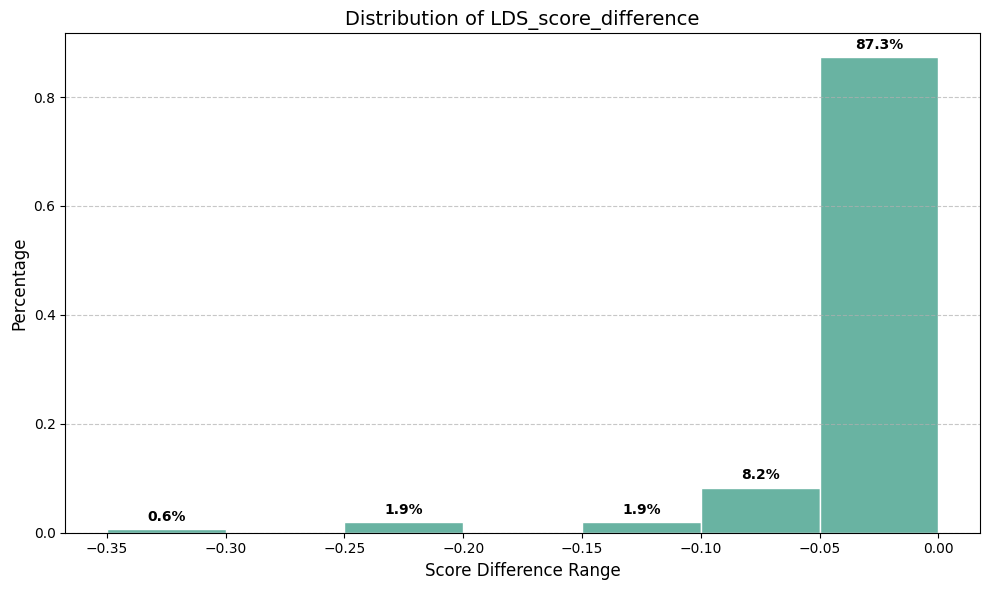

In [6]:
import matplotlib.pyplot as plt
import numpy as np

LDS_score_difference = [queries[2] for queries in LDS_lost_queries]

# 2. 设置分箱 (Bins)
# 从 -0.35 到 0，每隔 0.05 一个区间
bins = np.arange(-0.35, 0.05, 0.05)

# 3. 创建画布
plt.figure(figsize=(10, 6))

# 4. 绘制直方图
# weights 用于将频数转化为占比 (percentage)
counts, edges, bars = plt.hist(
    LDS_score_difference,
    bins=bins,
    edgecolor='white',
    color='#69b3a2',
    weights=np.ones(len(LDS_score_difference)) / len(LDS_score_difference)
)

# 5. 在直方图上方标出占比数值
for bar in bars:
    height = bar.get_height()
    if height > 0: # 仅在有数据的柱子上标注
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.1%}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# 6. 图表装饰
plt.title('Distribution of LDS_score_difference', fontsize=14)
plt.xlabel('Score Difference Range', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(bins) # 确保坐标轴刻度与分箱一致
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. 显示图像
plt.tight_layout()
plt.show()

In [7]:
[LDS_lost_index[i] for i in range(len(LDS_lost_queries)) if LDS_score_difference[i]<=-0.10]

[[4, 6, -0.10750582888722421],
 [11, 4, -0.24314834177494044],
 [14, 9, -0.103944793343544],
 [18, 4, -0.22210849896073337],
 [20, 6, -0.20948725044727323],
 [26, 5, -0.3321610875427723],
 [32, 2, -0.11873043924570081]]

In [8]:
[LDS_lost_queries[i] for i in range(len(LDS_lost_queries)) if LDS_score_difference[i]<=-0.10]

[['What about en route?',
  'What actions are taken by the Pilot Flying and Pilot Monitoring during the cruise phase of flight?',
  -0.10750582888722421],
 ['What is the primary method for tuning radios in the ARJ21 aircraft?',
  'What FMS page is used for descent preparation tasks such as STAR selection and wind input on the ARJ21?',
  -0.24314834177494044],
 ['What happens when you press a Line Select Key (LSK)?',
  'What action is initiated when a Line Select Key (LSK) is pressed?',
  -0.103944793343544],
 ['What is the purpose of the FIX function in FMS operations?',
  "What are the pilot's responsibilities during the cruise phase of flight, and what actions are involved in preparing for descent?",
  -0.22210849896073337],
 ['Can hold procedures be set up manually during the descent phase?',
  'During the descent phase, what procedures can be manually set up by the pilot?',
  -0.20948725044727323],
 ['In the ARJ21 aircraft, what is the primary tuning method for radios?',
  'During 

In [9]:
[LDS_lost_index[i] for i in range(len(LDS_lost_queries)) if -0.10<=LDS_score_difference[i]<=-0.05]
[LDS_lost_queries[i] for i in range(len(LDS_lost_queries)) if -0.10<=LDS_score_difference[i]<=-0.05]

[['What happens when one of these is selected?',
  'What is the function of the pushbuttons on the Flight Control Panel (FCP)?',
  -0.05549432635307311],
 ['What happens when a vertical Mode is selected?',
  'How are vertical modes engaged and disengaged through the Flight Control Panel?',
  -0.05713935345411303],
 ['And the Takeoff (TO) Mode?',
  'What does the Takeoff (TO) Mode do?',
  -0.08248042613267903],
 ['What position must the slides of the emergency exit doors always be in?',
  'How are the I type emergency exit doors operated?',
  -0.07264537215232847],
 ['Once the LEGS page with the HOLD AT prompt is shown, what should be done with the name of the waypoint needing the holding FIX?',
  'After the LEGS page displays the "HOLD AT" prompt, what information needs to be entered to define the holding FIX?',
  -0.059919105470180534],
 ['Where are the CDUs located in the aircraft?',
  'What kind of displays does the FMS support?',
  -0.06014345437288282],
 ['What message is annuncia

In [10]:
ESS_lost_index = []
for i in range(40):
  for j in range(len(ESS_current_scores[i])):
    current_score = sum(ESS_current_scores[i][j])/len(ESS_current_scores[i][j])
    rewritten_score = sum(ESS_rewritten_scores[i][j])/len(ESS_rewritten_scores[i][j])
    if (current_score > rewritten_score):
      ESS_lost_index.append([i,j,rewritten_score-current_score])

ESS_lost_queries = []
for i,j,k in ESS_lost_index:
  ESS_lost_queries.append([ESS_current_queries[i][j], ESS_rewritten_queries[i][j],k])

ESS_score_difference = [queries[2] for queries in ESS_lost_queries]

RNS_lost_index = []
for i in range(40):
  for j in range(len(RNS_current_scores[i])):
    current_score = sum(RNS_current_scores[i][j])/len(RNS_current_scores[i][j])
    rewritten_score = sum(RNS_rewritten_scores[i][j])/len(RNS_rewritten_scores[i][j])
    if (current_score > rewritten_score):
      RNS_lost_index.append([i,j,rewritten_score-current_score])

RNS_lost_queries = []
for i,j,k in RNS_lost_index:
  RNS_lost_queries.append([RNS_current_queries[i][j], RNS_rewritten_queries[i][j],k])

RNS_score_difference = [queries[2] for queries in RNS_lost_queries]

all_lost_index = LDS_lost_index + ESS_lost_index + RNS_lost_index
all_lost_queries = LDS_lost_queries + ESS_lost_queries + RNS_lost_queries
all_score_difference = LDS_score_difference + ESS_score_difference + RNS_score_difference

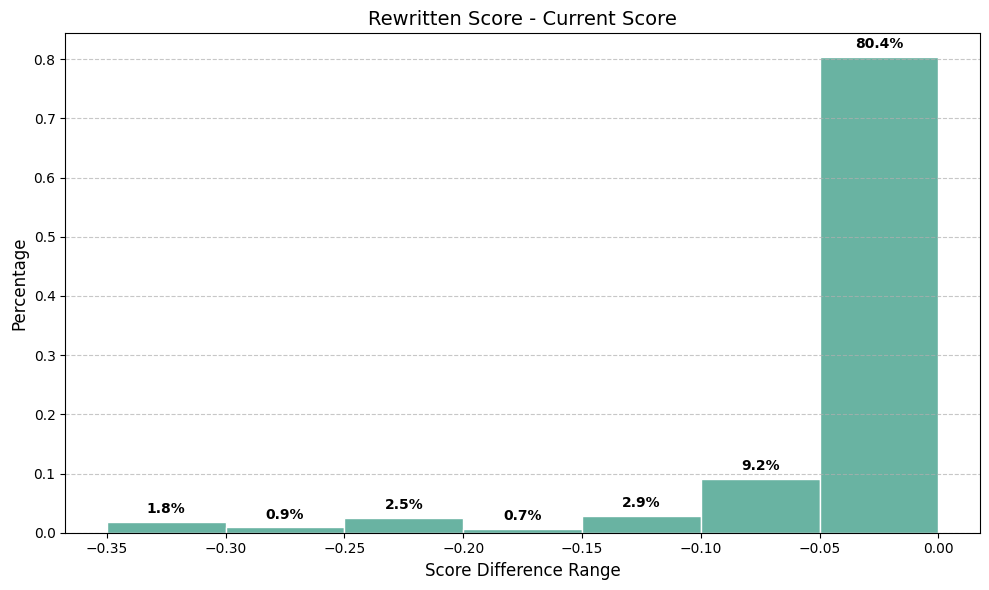

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# 2. 设置分箱 (Bins)
# 从 -0.35 到 0，每隔 0.05 一个区间
bins = np.arange(-0.35, 0.05, 0.05)

# 3. 创建画布
plt.figure(figsize=(10, 6))

# 4. 绘制直方图
# weights 用于将频数转化为占比 (percentage)
counts, edges, bars = plt.hist(
    all_score_difference,
    bins=bins,
    edgecolor='white',
    color='#69b3a2',
    weights=np.ones(len(all_score_difference)) / len(all_score_difference)
)

# 5. 在直方图上方标出占比数值
for bar in bars:
    height = bar.get_height()
    if height > 0: # 仅在有数据的柱子上标注
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f'{height:.1%}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# 6. 图表装饰
plt.title('Rewritten Score - Current Score', fontsize=14)
plt.xlabel('Score Difference Range', fontsize=12)
plt.ylabel('Percentage', fontsize=12)
plt.xticks(bins) # 确保坐标轴刻度与分箱一致
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. 显示图像
plt.tight_layout()
plt.show()

In [12]:
[all_lost_queries[i] for i in range(len(all_lost_queries)) if all_score_difference[i]<=-0.15]

[['What is the primary method for tuning radios in the ARJ21 aircraft?',
  'What FMS page is used for descent preparation tasks such as STAR selection and wind input on the ARJ21?',
  -0.24314834177494044],
 ['What is the purpose of the FIX function in FMS operations?',
  "What are the pilot's responsibilities during the cruise phase of flight, and what actions are involved in preparing for descent?",
  -0.22210849896073337],
 ['Can hold procedures be set up manually during the descent phase?',
  'During the descent phase, what procedures can be manually set up by the pilot?',
  -0.20948725044727323],
 ['In the ARJ21 aircraft, what is the primary tuning method for radios?',
  'During the cruise phase, what actions may a pilot be required to perform?',
  -0.3321610875427723],
 ['What are the two separate partitions of the Hydraulic Control Logic Electronics (HCLE)?',
  'What are the two partitions of the HCLE?',
  -0.17931335568428036],
 ['What does the VNAV CLIMB page show by default?'

In [13]:
[all_lost_queries[i] for i in range(len(all_lost_queries)) if -0.10<=all_score_difference[i]<=-0.05]

[['What happens when one of these is selected?',
  'What is the function of the pushbuttons on the Flight Control Panel (FCP)?',
  -0.05549432635307311],
 ['What happens when a vertical Mode is selected?',
  'How are vertical modes engaged and disengaged through the Flight Control Panel?',
  -0.05713935345411303],
 ['And the Takeoff (TO) Mode?',
  'What does the Takeoff (TO) Mode do?',
  -0.08248042613267903],
 ['What position must the slides of the emergency exit doors always be in?',
  'How are the I type emergency exit doors operated?',
  -0.07264537215232847],
 ['Once the LEGS page with the HOLD AT prompt is shown, what should be done with the name of the waypoint needing the holding FIX?',
  'After the LEGS page displays the "HOLD AT" prompt, what information needs to be entered to define the holding FIX?',
  -0.059919105470180534],
 ['Where are the CDUs located in the aircraft?',
  'What kind of displays does the FMS support?',
  -0.06014345437288282],
 ['What message is annuncia

In [14]:
all_lost_queries[10]

['What specific information does the PROGRESS 2/2 page display?',
 'What information is displayed on the PROGRESS 2/2 page?',
 -0.012510718405246757]

In [21]:
all_lost_index

[[0, 3, -0.003466364741325334],
 [0, 4, -0.013901963829994202],
 [0, 6, -0.01784351766109471],
 [0, 11, -0.026294600963592485],
 [0, 12, -0.023098169267177615],
 [0, 13, -0.007568392157554671],
 [0, 16, -0.001706920564174652],
 [0, 17, -0.021604233980178855],
 [0, 20, -0.001173782348632857],
 [2, 5, -0.017937248945236184],
 [2, 14, -0.012510718405246757],
 [3, 5, -0.05549432635307311],
 [3, 7, -0.01673954725265503],
 [3, 8, -0.026688413321971916],
 [3, 10, -0.011997556686401345],
 [3, 14, -0.013099987804889635],
 [4, 4, -0.005577737092971713],
 [4, 6, -0.10750582888722421],
 [5, 5, -0.009056071937084131],
 [5, 6, -0.022629284858703635],
 [6, 7, -0.01112432479858394],
 [6, 9, -0.01144058406352999],
 [6, 12, -0.013850614428520203],
 [6, 14, -0.0030521333217621294],
 [7, 5, -0.05713935345411303],
 [7, 6, -0.003950598835945063],
 [7, 7, -0.01784351766109471],
 [7, 8, -0.01035376638174057],
 [7, 9, -0.009111061692237854],
 [7, 10, -0.0014194846153259277],
 [7, 12, -0.03668036609888081],
 [7

In [23]:
all_lost_queries_and_indexs = []
for i in range(len(all_lost_queries)):
  all_lost_queries_and_indexs.append([all_lost_queries[i][0], all_lost_queries[i][1], all_lost_index[i][0], all_lost_index[i][1], all_lost_index[i][2]])

In [24]:
with open("/content/drive/MyDrive/Haystack/all_lost_queries_and_indexs.json", 'w', encoding='utf-8') as f:
  json.dump(all_lost_queries_and_indexs, f, indent= 3)